# NHL Contract Value Model

**Can a player's prior-season performance explain his NHL cap hit - and where does the market misprice talent?**

This notebook fits a linear model of a player's *cap hit as a share of the salary cap* from
seven on-ice and status features, then ranks every current contract by its **residual**
(actual minus predicted) to surface the most over- and under-paid deals.

It's a narrative walkthrough of the code in [`src/`](../src) - loading the data, the modeling
choices (why a *log-of-cap-percent* target), the fitted equation, honest cross-validated error,
and what the residuals reveal. Nothing here re-implements the model; it calls the same functions
the Streamlit dashboard uses.

> A **value/inefficiency tool, not a crystal ball.** The model can only price what the market
> already rewards - it can't see prospect upside, intangibles, or negotiation leverage, which is
> exactly what its biggest residuals are made of.


In [1]:
import os, sys
# run from the repo root whether this notebook is opened there or in notebooks/,
# so `import src...` and the relative data/ paths both resolve
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# the project's own modules - the same code the dashboard runs on
from src.model import prepare, prepare_goalies, cross_validated_scores, FEATURES, GOALIE_FEATURES, TARGET
from src.generate_rankings import _training_signings
from src.cap_ceilings import CAP_CEILING

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.axisbelow": True})

# validated colorblind-safe diverging pair (same as the dashboard)
OVER, UNDER, NEUTRAL = "#cc3311", "#0077bb", "#9aa4b2"
CEILING_2627 = CAP_CEILING["20262027"]   # $104.0M - the cap we price predictions against
print("modules loaded - cap ceiling 2026-27 = ${:,}".format(CEILING_2627))


modules loaded - cap ceiling 2026-27 = $104,000,000


## 1. The data

Two skater populations, both built by the pipeline in `src/`:

- **Training set** - the free-market **signings from 2024-2026** (`_training_signings()`), each
  priced against the cap ceiling of the year it was signed. Fresh deals price star/upside
  production properly; a whole-league fit gets diluted by cheap legacy, RFA, and entry-level contracts.
- **Scoring set** - **every current NHL skater**, whom we value once the model is fit.

`prepare()` does the cleaning: it drops noisy low-games rows and buried/retained sub-minimum
cap hits, encodes `is_ufa` / `is_defense`, and builds the log target.


In [2]:
train = _training_signings()                                   # 2024-2026 free-market signings
current = prepare(pd.read_csv("data/processed/skaters_current_dataset.csv"))

print(f"training signings : {len(train):>4} rows")
print(f"current skaters   : {len(current):>4} rows")
print(f"features          : {FEATURES}")
print(f"target            : {TARGET}  (= log of cap_hit / season cap ceiling)")

train[["player_name", "team", "position", "age", "contract_type",
       "points_per_60", "toi_per_gp_min", "cap_hit", "cap_hit_pct"]].head()


training signings :  645 rows
current skaters   :  652 rows
features          : ['points_per_60', 'ixg_per_60', 'toi_per_gp_min', 'games_played', 'age', 'is_ufa', 'is_defense']
target            : log_cap_hit_pct  (= log of cap_hit / season cap ceiling)


,player_name,team,position,age,contract_type,points_per_60,toi_per_gp_min,cap_hit,cap_hit_pct
0,John Beecher,Boston Bruins,C,25,RFA,1.086,10.624,900000,0.010
1,Evan Bouchard,Edmonton Oilers,D,26,RFA,2.641,22.997,10500000,0.119
2,Declan Chisholm,Washington Capitals,D,26,RFA,1.054,16.529,1600000,0.018
3,Nick Cousins,Ottawa Senators,C,33,UFA,1.070,12.186,825000,0.009
4,Aaron Ekblad,Florida Panthers,D,30,UFA,1.015,20.863,6100000,0.069


## 2. Why model *log(cap %)*, not raw dollars

Two problems with predicting raw AAV directly:

1. **The cap moves.** A \$8M deal in 2018 (\$79.5M ceiling) is a bigger commitment than \$8M
   today (\$104M). Modeling **cap hit as a percent of that season's ceiling** puts every contract
   on one comparable scale, so signings from different years can be pooled.
2. **Salaries are multiplicative and right-skewed.** Most players cluster cheap; a few stars run
   an order of magnitude higher. A **log** transform turns that skew roughly symmetric and makes
   the model additive in *percentage* terms - a coefficient means "+X% of cap per unit," which is
   how contracts actually scale.

The plots below show the rising cap, the raw-dollar skew, and how the log fixes it.


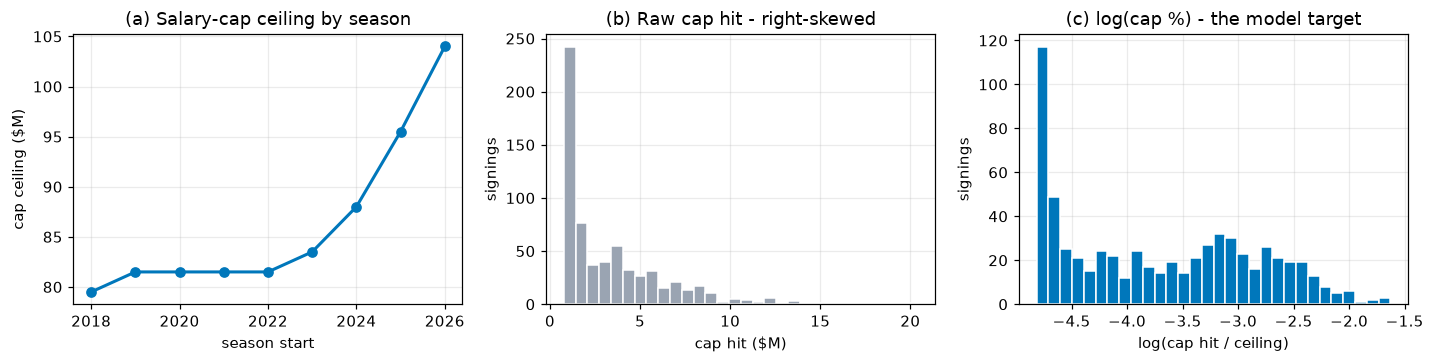

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

# (a) the cap ceiling has climbed ~30% in 8 years
seasons = sorted(CAP_CEILING)
yrs = [int(s[:4]) for s in seasons]
ax[0].plot(yrs, [CAP_CEILING[s] / 1e6 for s in seasons], "-o", color=UNDER, lw=2)
ax[0].set(title="(a) Salary-cap ceiling by season", xlabel="season start", ylabel="cap ceiling ($M)")

# (b) raw cap hit - heavy right skew
ax[1].hist(train["cap_hit"] / 1e6, bins=30, color=NEUTRAL, edgecolor="white")
ax[1].set(title="(b) Raw cap hit - right-skewed", xlabel="cap hit ($M)", ylabel="signings")

# (c) log(cap %) - roughly symmetric, model-friendly
ax[2].hist(np.log(train["cap_hit_pct"]), bins=30, color=UNDER, edgecolor="white")
ax[2].set(title="(c) log(cap %) - the model target", xlabel="log(cap hit / ceiling)", ylabel="signings")

plt.tight_layout(); plt.show()


## 3. What moves a contract? (EDA)

Before fitting, look at how each feature co-moves with pay. Two things to notice:

- **Ice time (`toi_per_gp_min`) and scoring rate (`points_per_60`)** track cap % most strongly -
  coaches give their best players minutes, and the market pays for both.
- **`is_defense` is a headwind.** Defensemen play *more* minutes yet the market pays their
  points less, so the raw position flag correlates slightly negatively with cap % - a real effect
  the model will pick up.


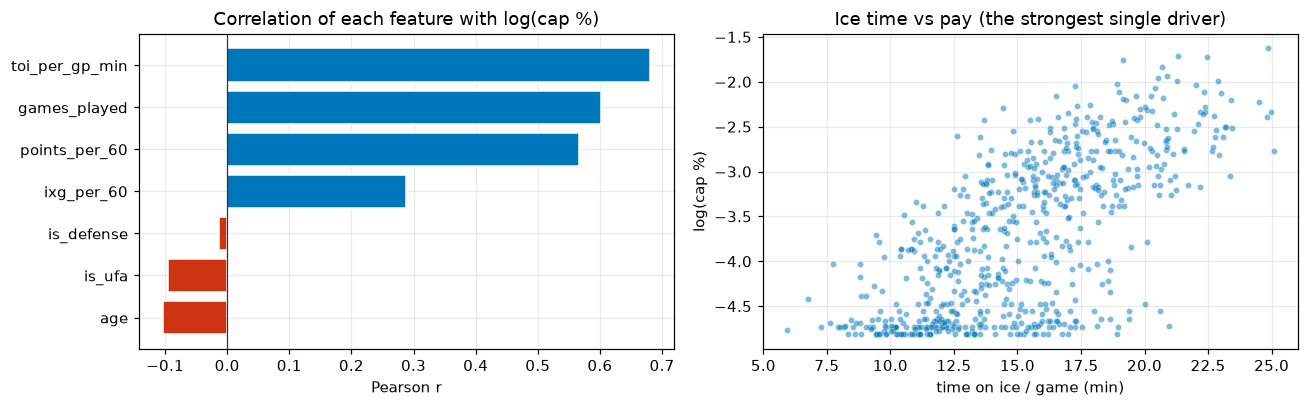

,corr_with_log_cap_pct
age,-0.103
is_ufa,-0.095
is_defense,-0.013
ixg_per_60,0.287
points_per_60,0.566
games_played,0.601
toi_per_gp_min,0.680


In [4]:
num = ["points_per_60", "ixg_per_60", "toi_per_gp_min", "games_played", "age", "is_ufa", "is_defense"]
corr = train[num + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
colors = [UNDER if v >= 0 else OVER for v in corr.values]
ax[0].barh(corr.index, corr.values, color=colors, edgecolor="white")
ax[0].axvline(0, color="#333", lw=0.8)
ax[0].set(title="Correlation of each feature with log(cap %)", xlabel="Pearson r")

ax[1].scatter(train["toi_per_gp_min"], np.log(train["cap_hit_pct"]),
              s=16, alpha=0.5, color=UNDER, edgecolor="white", linewidth=0.3)
ax[1].set(title="Ice time vs pay (the strongest single driver)",
          xlabel="time on ice / game (min)", ylabel="log(cap %)")
plt.tight_layout(); plt.show()

corr.to_frame("corr_with_log_cap_pct")


## 4. The model and its equation

A plain **ordinary-least-squares linear regression** on standardized features
(`StandardScaler` -> `LinearRegression`). Standardizing puts every coefficient in the same units -
**change in log(cap %) per one standard deviation of that feature** - so their magnitudes are
directly comparable.

We fit on the 2024-2026 signings and print the equation with its coefficients.


In [5]:
pipe = make_pipeline(StandardScaler(), LinearRegression()).fit(train[FEATURES], train[TARGET])
scaler, lr = pipe.named_steps["standardscaler"], pipe.named_steps["linearregression"]

coefs = pd.DataFrame({
    "feature": FEATURES,
    "mean": scaler.mean_,
    "std": scaler.scale_,
    "coef (per 1 SD)": lr.coef_,
}).sort_values("coef (per 1 SD)", key=abs, ascending=False).reset_index(drop=True)

print(f"intercept = {lr.intercept_:.4f}\n")
print("Fitted equation:")
print("  log(cap_hit / ceiling) = {:.3f}".format(lr.intercept_))
for f, c in zip(FEATURES, lr.coef_):
    print("      {:+.3f} * z({})".format(c, f))
print("\n  predicted_cap_hit = ceiling * exp( the above ),   ceiling = $104.0M")
print("  z(x) = (x - mean) / std   (standardized using the columns below)")
coefs


intercept = -3.7124

Fitted equation:
  log(cap_hit / ceiling) = -3.712
      +0.166 * z(points_per_60)
      +0.108 * z(ixg_per_60)
      +0.510 * z(toi_per_gp_min)
      +0.216 * z(games_played)
      -0.210 * z(age)
      +0.076 * z(is_ufa)
      -0.062 * z(is_defense)

  predicted_cap_hit = ceiling * exp( the above ),   ceiling = $104.0M
  z(x) = (x - mean) / std   (standardized using the columns below)


,feature,mean,std,coef (per 1 SD)
0,toi_per_gp_min,15.201,3.641,0.510
1,games_played,61.986,18.803,0.216
2,age,29.129,4.347,-0.210
3,points_per_60,1.431,0.745,0.166
4,ixg_per_60,0.599,0.364,0.108
5,is_ufa,0.688,0.463,0.076
6,is_defense,0.341,0.474,-0.062


**Reading the coefficients.** Ice time per game is by far the largest lever, followed by age
(negative - the market pays for youth/term), games played (durability), and scoring rate. `ixg_per_60`
(individual expected goals - shot quality) adds a smaller independent bump. `is_defense` carries a
**negative** sign even after controlling for minutes and scoring: a blueliner with the same box-score
line as a forward is priced lower. That's not the model's opinion - it's the market's, and it's the
kind of structural bias the residuals will expose.


## 5. Honest error: cross-validation

In-sample fit flatters a model. `cross_validated_scores()` runs **5-fold cross-validation** -
each signing is predicted by a model that never saw it - and back-transforms the log prediction
to dollars against the \$104M ceiling so the error is in cap-hit terms you can feel.


In [6]:
s = cross_validated_scores(train, features=FEATURES)
print("5-fold cross-validated performance (2024-2026 signings):")
print(f"  R^2 on log(cap %) : {s['r2_log']:.3f}")
print(f"  mean abs error    : ${s['mae_dollars']:,.0f}")
print(f"  median abs error  : ${s['median_ae_dollars']:,.0f}")


5-fold cross-validated performance (2024-2026 signings):
  R^2 on log(cap %) : 0.708
  mean abs error    : $1,129,153
  median abs error  : $759,516


An **R² of ~0.71** on genuinely out-of-sample deals, with a typical miss around **\$1.1M**, is a
strong result for a 7-feature linear model of something as messy as contract negotiation. The
median error is well under the mean - most predictions are tight, and a handful of hard-to-price
deals (the very residuals we're hunting) pull the average up.


## 6. Diagnostic: predicted vs. actual

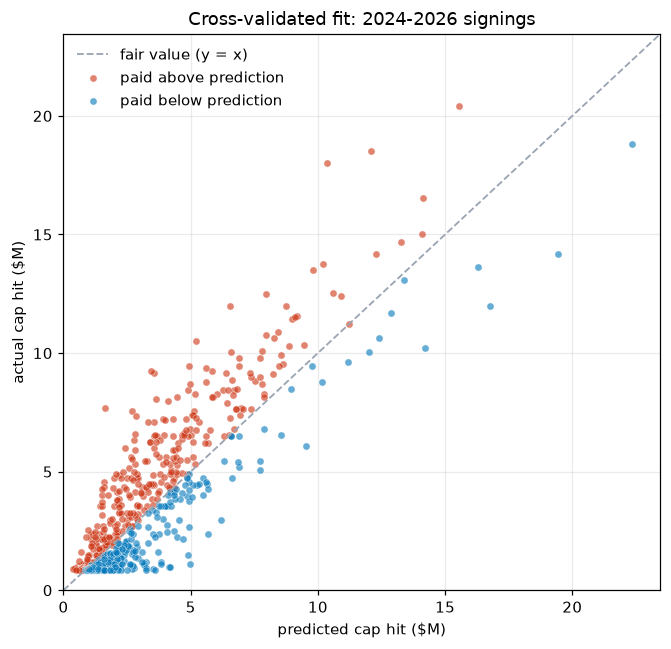

In [7]:
from sklearn.model_selection import cross_val_predict, KFold
kf = KFold(n_splits=5, shuffle=True, random_state=0)
pred_log = cross_val_predict(pipe, train[FEATURES], train[TARGET], cv=kf)
pred = np.exp(pred_log) * CEILING_2627 / 1e6
act = np.exp(train[TARGET].values) * CEILING_2627 / 1e6

resid = act - pred
fig, ax = plt.subplots(figsize=(6.2, 6))
lim = max(act.max(), pred.max()) * 1.05
ax.plot([0, lim], [0, lim], "--", color=NEUTRAL, lw=1.2, label="fair value (y = x)")
ax.scatter(pred[resid >= 0], act[resid >= 0], s=22, alpha=0.6, color=OVER,
           edgecolor="white", linewidth=0.4, label="paid above prediction")
ax.scatter(pred[resid < 0], act[resid < 0], s=22, alpha=0.6, color=UNDER,
           edgecolor="white", linewidth=0.4, label="paid below prediction")
ax.set(xlim=(0, lim), ylim=(0, lim), xlabel="predicted cap hit ($M)",
       ylabel="actual cap hit ($M)", title="Cross-validated fit: 2024-2026 signings")
ax.legend(frameon=False, loc="upper left"); plt.tight_layout(); plt.show()


## 7. The payoff: who's over- and under-paid?

Now fit on all 2024-2026 signings and value **every current skater**, then sort by residual.
Predictions are deliberately **not capped** at the \$20.8M max-contract limit, so an elite
player's modeled value can run above what any contract could legally pay - the overage is a
measure of how far his production outstrips the cap.


In [8]:
pipe_full = make_pipeline(StandardScaler(), LinearRegression()).fit(train[FEATURES], train[TARGET])
pred_pct = np.exp(pipe_full.predict(current[FEATURES]))
rank = current[["player_name", "team", "position", "age", "contract_type", "cap_hit"]].copy()
rank["predicted_cap_hit"] = (pred_pct * CEILING_2627).round()
rank["residual"] = rank["cap_hit"] - rank["predicted_cap_hit"]

def money(df):
    d = df.copy()
    for c in ["cap_hit", "predicted_cap_hit", "residual"]:
        d[c] = (d[c] / 1e6).map(lambda v: f"${v:+.1f}M" if c == "residual" else f"${v:.1f}M")
    return d

print("Most OVERPAID (actual >> predicted):")
over = rank.sort_values("residual", ascending=False).head(10)
display(money(over[["player_name", "team", "position", "age", "contract_type",
                    "cap_hit", "predicted_cap_hit", "residual"]]).reset_index(drop=True))

print("Most UNDERPAID (actual << predicted):")
under = rank.sort_values("residual").head(10)
display(money(under[["player_name", "team", "position", "age", "contract_type",
                     "cap_hit", "predicted_cap_hit", "residual"]]).reset_index(drop=True))


Most OVERPAID (actual >> predicted):


,player_name,team,position,age,contract_type,cap_hit,predicted_cap_hit,residual
0,Tyler Seguin,Dallas Stars,C,34,UFA,$9.8M,$2.2M,$+7.7M
1,Leo Carlsson,Anaheim Ducks,C,21,RFA,$18.0M,$10.7M,$+7.3M
2,Jonathan Huberdeau,Calgary Flames,L,33,UFA,$10.5M,$3.5M,$+7.0M
3,Drew Doughty,Los Angeles Kings,D,36,UFA,$11.0M,$4.7M,$+6.3M
4,Victor Hedman,Tampa Bay Lightning,D,35,UFA,$8.0M,$2.1M,$+5.9M
5,Pierre-Luc Dubois,Washington Capitals,C,28,UFA,$8.5M,$3.2M,$+5.3M
6,Jared Spurgeon,Minnesota Wild,D,36,UFA,$7.6M,$3.1M,$+4.5M
7,Ondrej Palat,New York Islanders,L,35,UFA,$6.0M,$1.7M,$+4.3M
8,Darnell Nurse,San Jose Sharks,D,31,UFA,$9.2M,$5.0M,$+4.3M
9,Elias Pettersson,Vancouver Canucks,C,27,UFA,$11.6M,$7.4M,$+4.2M


Most UNDERPAID (actual << predicted):


,player_name,team,position,age,contract_type,cap_hit,predicted_cap_hit,residual
0,Macklin Celebrini,San Jose Sharks,C,20,RFA,$1.0M,$22.1M,$-21.1M
1,Matthew Schaefer,New York Islanders,D,19,RFA,$1.0M,$16.8M,$-15.8M
2,Connor McDavid,Edmonton Oilers,C,29,UFA,$12.5M,$25.7M,$-13.2M
3,Quinn Hughes,Minnesota Wild,D,26,UFA,$7.8M,$20.9M,$-13.0M
4,Beckett Sennecke,Anaheim Ducks,R,20,RFA,$1.0M,$9.7M,$-8.7M
5,Will Smith,San Jose Sharks,C,21,RFA,$0.9M,$8.8M,$-7.8M
6,Nick Suzuki,Montreal Canadiens,C,27,UFA,$7.9M,$15.7M,$-7.8M
7,Zach Werenski,Columbus Blue Jackets,D,29,UFA,$9.6M,$17.1M,$-7.5M
8,Nathan MacKinnon,Colorado Avalanche,C,31,UFA,$12.6M,$20.0M,$-7.4M
9,Evan Bouchard,Edmonton Oilers,D,26,UFA,$10.5M,$17.6M,$-7.1M


The two tails are interpretable, which is the real test of whether the model learned something:

- **"Overpaid"** is mostly **young stars on upside-priced deals** whose production hasn't yet caught
  up to the money, plus a few genuine declining veterans.
- **"Underpaid"** splits in two: **entry-level rookies** who are cap-capped by the CBA (underpaid by
  construction), and **genuine below-market veterans** - the model's actual finding.


## 8. A model can only value what the market rewards

The most important lesson of the project is a *negative* result. We tried to make the model reward
things fans care about - defense and goaltending quality - and the market simply doesn't pay for them
enough to matter:

- **Skater defense.** Adding on-ice defensive metrics barely moved accuracy and, when weighted
  heavily, wildly *over*-valued stay-at-home defensemen. The market prices offense; the model has to
  as well. (Explored in `src/experiment_features.py`.)
- **Goalies.** A separate, smaller model shows goalie pay is almost entirely **workload** - how many
  games you start, i.e. whether you're the clear #1 - not save quality. Shot-quality-adjusted **GSAx**
  (goals saved above expected, scraped from Natural Stat Trick) added essentially nothing.

The cell below makes the goalie point concrete: `games_started` **alone** captures almost all of what
the full goalie model does.


In [9]:
goalies = prepare_goalies(pd.read_csv("data/processed/goalies_current_dataset.csv"))
full = cross_validated_scores(goalies, features=GOALIE_FEATURES)["r2_log"]
starts_only = cross_validated_scores(goalies, features=["games_started"])["r2_log"]

print(f"goalies in sample                : {len(goalies)}")
print(f"full goalie model ({', '.join(GOALIE_FEATURES)}) R^2 : {full:.3f}")
print(f"games_started ALONE           R^2 : {starts_only:.3f}")
print(f"-> everything beyond workload adds only {full - starts_only:+.3f} R^2")


goalies in sample                : 55
full goalie model (games_started, age, is_ufa) R^2 : 0.437
games_started ALONE           R^2 : 0.404
-> everything beyond workload adds only +0.032 R^2


## 9. Limitations and takeaways

- **Descriptive, not causal.** Residuals describe *the gap between pay and a market-fit model*, not
  a player's true worth. A big residual can mean a bad contract - or a signal the market sees that
  seven box-score features don't.
- **ELC rookies look underpaid by construction.** Their cap hit is CBA-capped, so the model will
  always "predict" more than they're allowed to earn.
- **The model inherits the market's blind spots.** Because it's fit on real contracts, it undervalues
  exactly what the market undervalues (elite defense, goaltending quality). It can flag inefficiency
  only relative to how NHL GMs already pay - not against some ground truth of value.
- **Goalies are a small, secondary model** (~55 contracts) and should be read as a rough workload proxy.

**Takeaway:** a simple, honest linear model on well-chosen features explains ~71% of the variation in
NHL cap hits and produces interpretable over/under-pay rankings - and its *failures* (defense, goalies)
are as informative as its fit, because they map precisely onto the market's own inefficiencies.

*Explore the rankings interactively in the Streamlit dashboard (`streamlit run app.py`); see
`NOTES.md` for the full log of decisions and dead ends.*
